# SA 1.1: Bipartite Network Graph - Sphere Definitions

This notebook visualizes the relationship between books and three specific content keywords (CKs) related to the definition of a sphere:
1. **CK_Definition of Sphere by Euclid**
2. **CK_Definition of Sphere by Theodosius**
3. **CK_Additions on Definitions of the Sphere**

The graph is bipartite, with books colored by their `place_category` (Large, Medium, Small, or One Book Center) and CKs represented as grey nodes.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches
import os

In [6]:
# Load data
image_df = pd.read_csv('../../DATA/02_image_clusters/full_image_data_feb_25.csv', low_memory=False)
book_df = pd.read_csv('../../DATA/01_corpus_metadata/full_book_data_feb_25.csv', low_memory=False)

print(f"Loaded {len(image_df)} images and {len(book_df)} books.")

FileNotFoundError: [Errno 2] No such file or directory: '../DATA/02_image_clusters/full_image_data_feb_25.csv'

In [ ]:
# Filter for the target CKs
target_cks = [
    'CK_Definition of Sphere by Euclid',
    'CK_Definition of Sphere by Theodosius',
    'CK_Additions on Definitions of the Sphere'
]

filtered_df = image_df[image_df['cks'].isin(target_cks)].copy()

print(f"Filtered dataset contains {len(filtered_df)} images across {filtered_df['book'].nunique()} unique books.")

In [4]:
# Define the color map for place categories (based on SA_1.1.ipynb)
category_color_map = {
    'Large Center': 'skyblue',
    'Medium Center': 'salmon',
    'Small Center': 'lightgreen',
    'One Book Center': 'khaki'
}

# Create the graph
G = nx.Graph()

# Add nodes for CKs
for ck in target_cks:
    G.add_node(ck, type='ck')

# Add nodes for books and edges to CKs
# We filter for unique book-CK pairs to build edges
for _, row in filtered_df.drop_duplicates(subset=['book', 'cks']).iterrows():
    book = row['book']
    ck = row['cks']
    
    if not G.has_node(book):
        place_cat = row['place_category']
        G.add_node(book, type='book', category=place_cat)
    
    G.add_edge(book, ck)

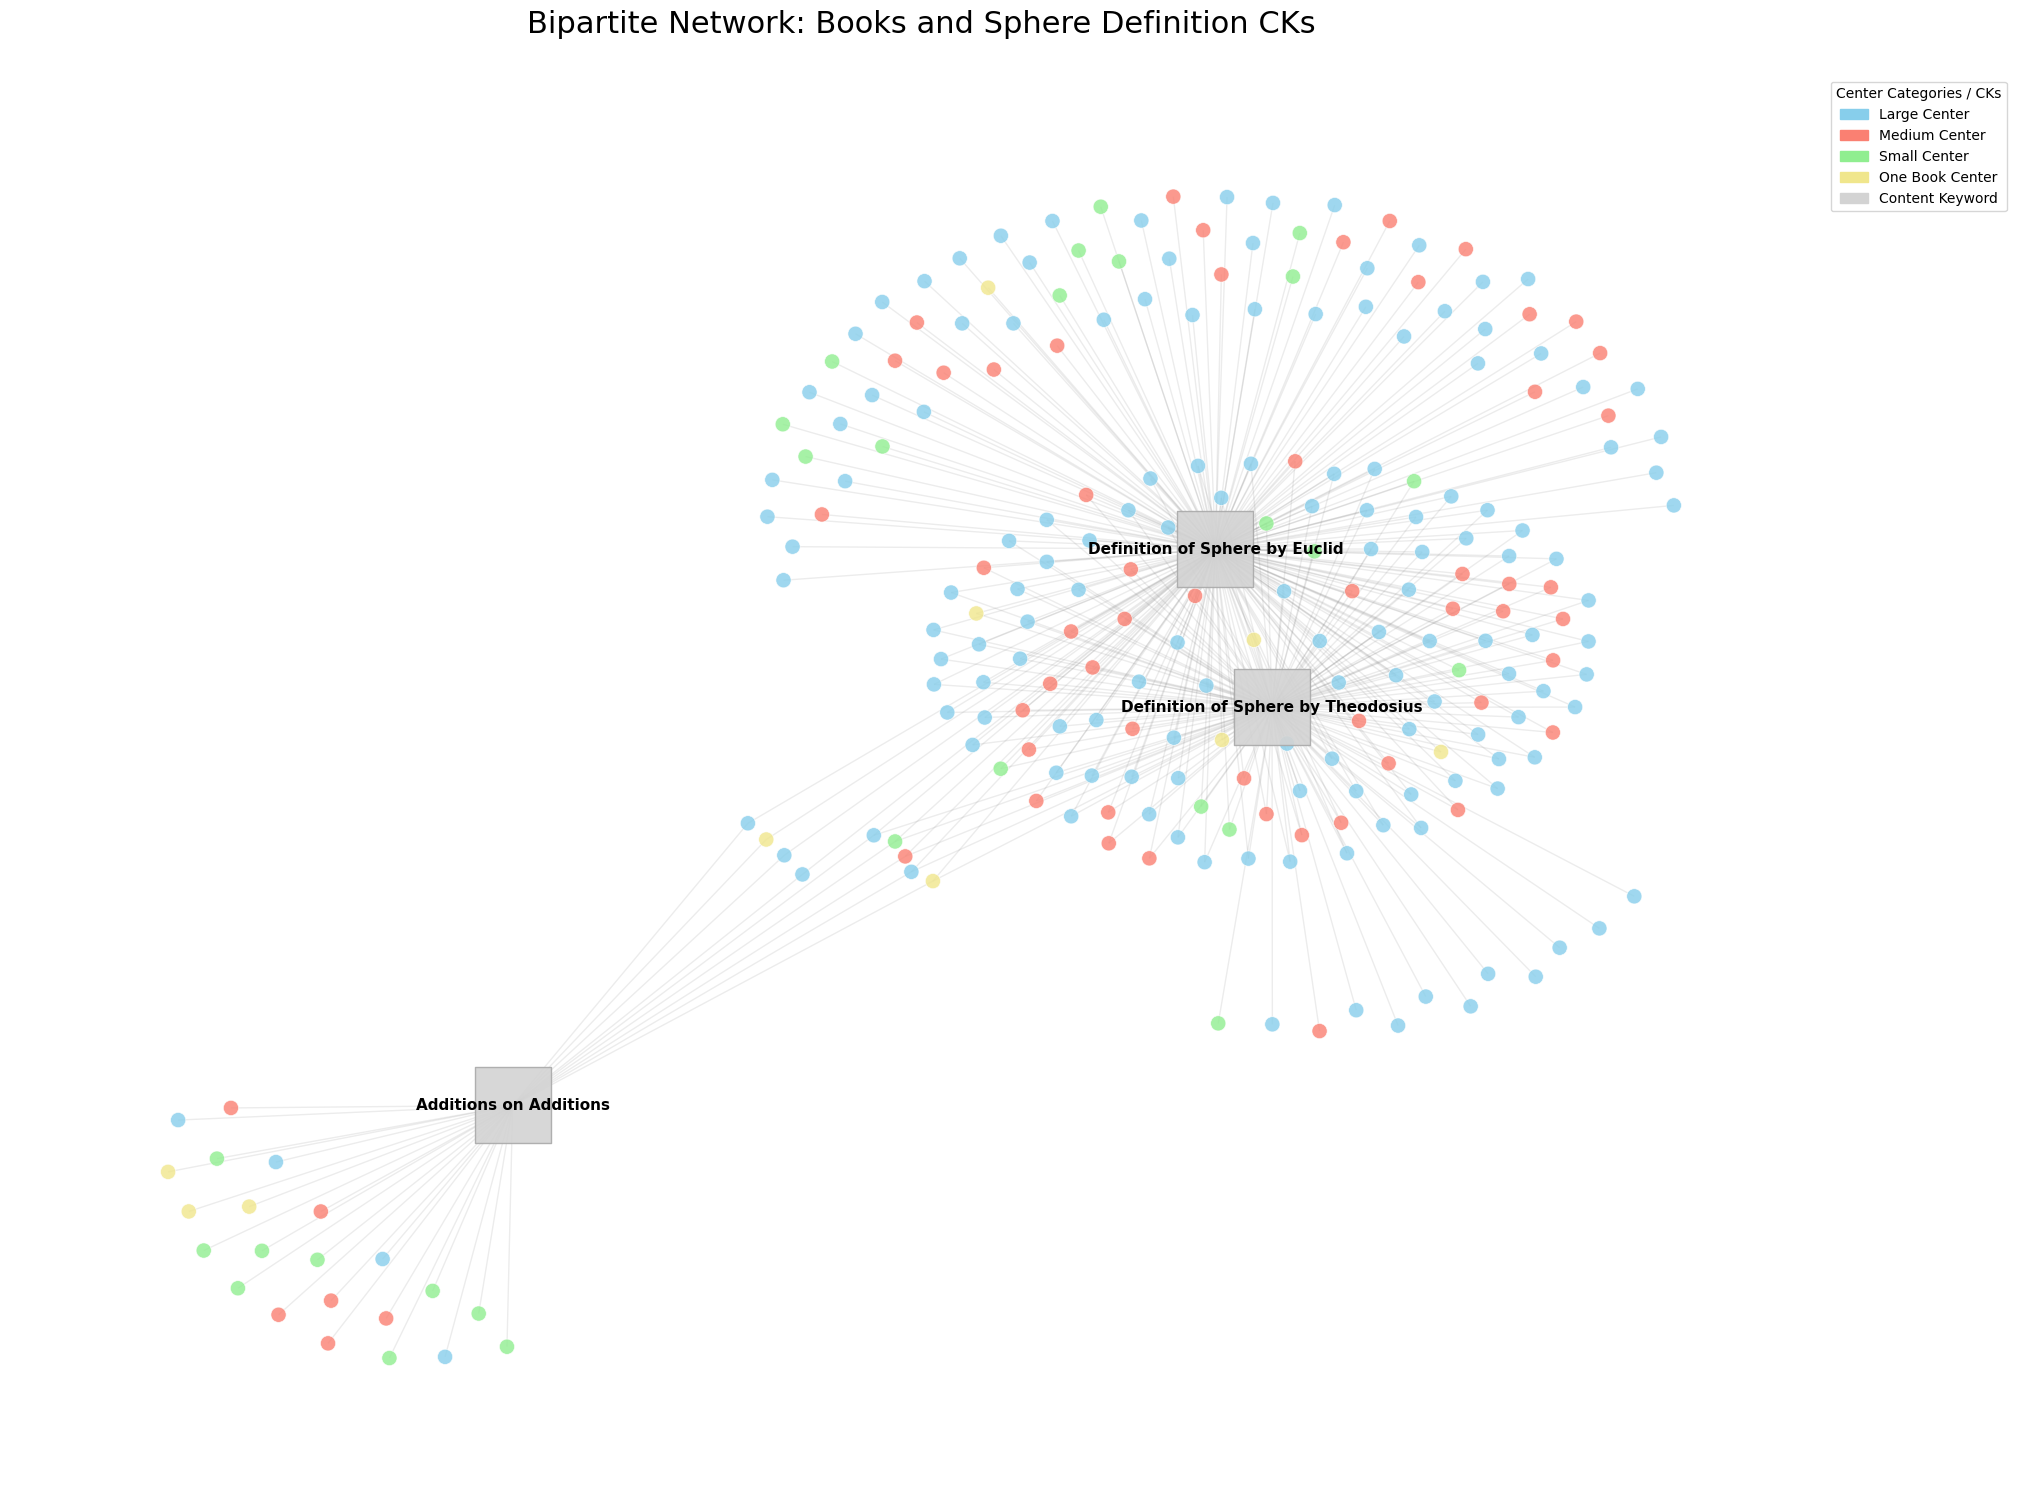

In [6]:
# Set node colors
node_colors_list = []
for node, data in G.nodes(data=True):
    if data['type'] == 'ck':
        node_colors_list.append('lightgray')
    else:
        cat = data.get('category', 'Other')
        node_colors_list.append(category_color_map.get(cat, 'gray'))

# Plotting
plt.figure(figsize=(20, 15))
# Use sparse layout to accommodate many book nodes
pos = nx.spring_layout(G, k=0.08, iterations=100, seed=42)

# Draw book nodes
book_nodes = [n for n, d in G.nodes(data=True) if d['type'] == 'book']
book_colors = [node_colors_list[list(G.nodes()).index(n)] for n in book_nodes]
nx.draw_networkx_nodes(
    G, pos, 
    nodelist=book_nodes,
    node_color=book_colors,
    node_size=120,
    alpha=0.8,
    edgecolors='white', # border for nodes
    linewidths=0.5
)

# Draw CK nodes (larger and square)
ck_nodes = [n for n, d in G.nodes(data=True) if d['type'] == 'ck']
nx.draw_networkx_nodes(
    G, pos, 
    nodelist=ck_nodes,
    node_color='lightgray',
    node_size=3000,
    node_shape='s', 
    alpha=0.9,
    edgecolors='darkgray'
)

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.15, edge_color='gray')

# Draw labels for CK nodes - using simplified names if needed
ck_labels = {n: n.replace('CK_', '').replace('Definitions of the Sphere', 'Additions') for n in ck_nodes}
nx.draw_networkx_labels(G, pos, labels=ck_labels, font_size=11, font_weight='bold')

# Legend
legend_handles = [mpatches.Patch(color=color, label=cat) for cat, color in category_color_map.items()]
legend_handles.append(mpatches.Patch(color='lightgray', label='Content Keyword'))
plt.legend(handles=legend_handles, title='Center Categories / CKs', loc='upper right', bbox_to_anchor=(1.1, 1))

plt.title("Bipartite Network: Books and Sphere Definition CKs", fontsize=22, pad=30)
plt.axis('off')
plt.tight_layout()

# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/sphere_definition_network.png', dpi=300)


plt.show()